In [45]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import seaborn as sns

In [46]:
df=sns.load_dataset("iris")
df.head

<bound method NDFrame.head of      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]>

In [47]:
from sklearn.preprocessing import LabelEncoder

encode=LabelEncoder()
df['species']=encode.fit_transform(df['species'])
df.head

<bound method NDFrame.head of      sepal_length  sepal_width  petal_length  petal_width  species
0             5.1          3.5           1.4          0.2        0
1             4.9          3.0           1.4          0.2        0
2             4.7          3.2           1.3          0.2        0
3             4.6          3.1           1.5          0.2        0
4             5.0          3.6           1.4          0.2        0
..            ...          ...           ...          ...      ...
145           6.7          3.0           5.2          2.3        2
146           6.3          2.5           5.0          1.9        2
147           6.5          3.0           5.2          2.0        2
148           6.2          3.4           5.4          2.3        2
149           5.9          3.0           5.1          1.8        2

[150 rows x 5 columns]>

In [48]:
new_df=df[['sepal_width','sepal_length','species']]
new_df.head

<bound method NDFrame.head of      sepal_width  sepal_length  species
0            3.5           5.1        0
1            3.0           4.9        0
2            3.2           4.7        0
3            3.1           4.6        0
4            3.6           5.0        0
..           ...           ...      ...
145          3.0           6.7        2
146          2.5           6.3        2
147          3.0           6.5        2
148          3.4           6.2        2
149          3.0           5.9        2

[150 rows x 3 columns]>

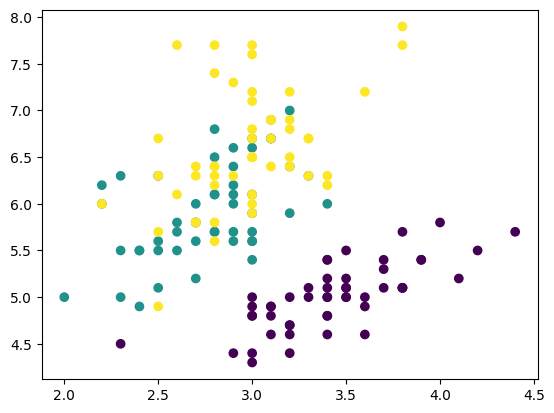

In [49]:
import matplotlib.pyplot as plt
plt.scatter(df['sepal_width'],df['sepal_length'],c=df['species'])

In [50]:
# Taking only 10 rows for training
df = new_df.sample(100)
df_train = df.iloc[:60,:].sample(10) #train
df_val = df.iloc[60:80,:].sample(5) #validation
df_test = df.iloc[80:,:].sample(5)# test

In [51]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [52]:
# BAGGING

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,sepal_length,species
138,3.0,6.0,2
108,2.5,6.7,2
44,3.8,5.1,0
112,3.0,6.8,2
138,3.0,6.0,2
112,3.0,6.8,2
138,3.0,6.0,2
93,2.3,5.0,1


In [53]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [54]:
dt_bag1 = DecisionTreeClassifier()

In [55]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

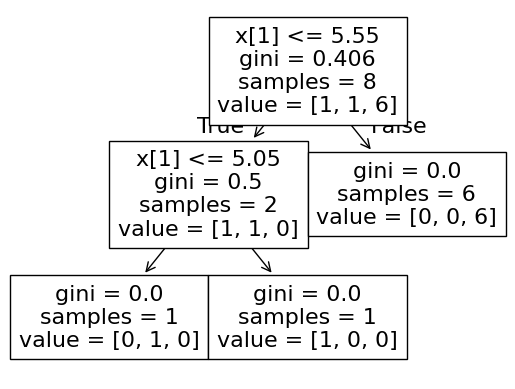

0.4


c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


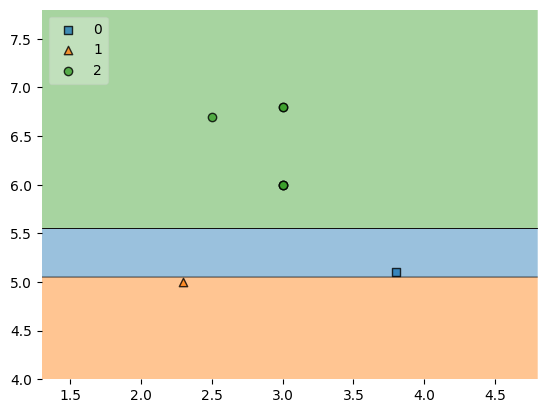

In [56]:
evaluate(dt_bag1,X,y)

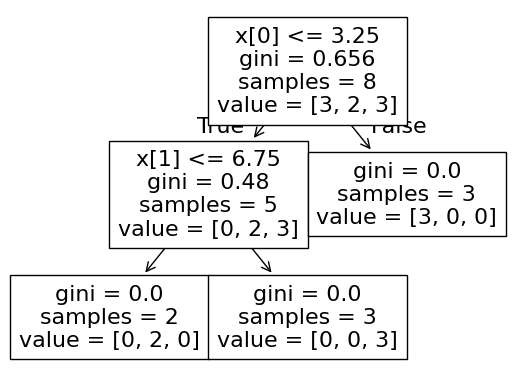

0.6


c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


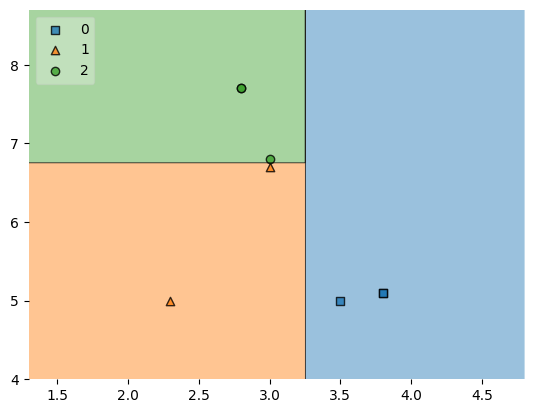

In [57]:
# Data for Tree 2
df_bag2 = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag2.iloc[:,0:2]
y = df_bag2.iloc[:,-1]

# print df_bag
df_bag


dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

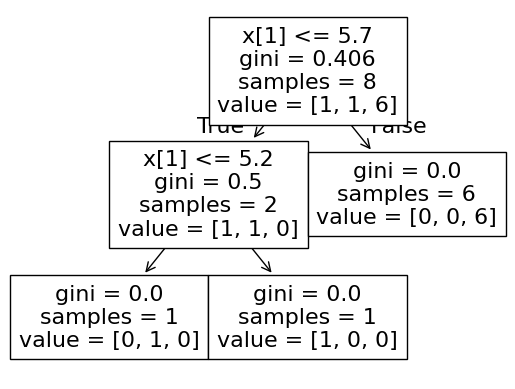

0.4


c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


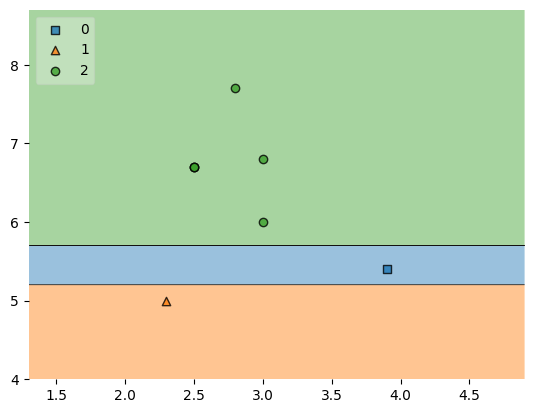

In [58]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag


dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [59]:
# Predict
print("Predictor 1",dt_bag1.predict(np.array([2.7,4.1]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.9,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.9,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Preethika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
